# 📊 Customer Features - Exploratory Data Analysis

Notebook trực quan hóa và mô tả bộ dữ liệu `customer_features.csv` được tạo ra từ pipeline tiền xử lý Instacart.

**Các đặc trưng (features):**
| Feature | Mô tả |
|---|---|
| `user_id` | Mã khách hàng |
| `total_orders` | Tổng số đơn hàng |
| `average_days_between_orders` | Số ngày trung bình giữa các đơn |
| `reorder_rate` | Tỉ lệ đặt lại sản phẩm đã mua |
| `avg_basket_size` | Kích thước giỏ hàng trung bình |
| `unique_products` | Số sản phẩm unique đã mua |
| `weekend_ratio` | Tỉ lệ đặt hàng vào cuối tuần |
| `night_order_ratio` | Tỉ lệ đặt hàng ban đêm |
| `organic_ratio_order` | Tỉ lệ sản phẩm organic trong đơn hàng |

In [1]:
# === Import Libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#1a1d23',
    'axes.edgecolor': '#2d3139',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.alpha': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 120
})

# Custom color palette
COLORS = {
    'primary': '#58a6ff',
    'secondary': '#bc8cff',
    'accent': '#7ee787',
    'warm': '#f0883e',
    'danger': '#f85149',
    'info': '#79c0ff',
    'gradient': ['#58a6ff', '#bc8cff', '#f0883e', '#7ee787', '#f85149', '#79c0ff']
}

print('✅ Libraries loaded & style configured!')

✅ Libraries loaded & style configured!


## 1. 📥 Load & Inspect Data

In [2]:
# Load dataset
df = pd.read_csv('customer_features.csv')

print(f'📦 Shape: {df.shape[0]:,} khách hàng × {df.shape[1]} features')
print(f'💾 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print()
df.head(10)

📦 Shape: 206,209 khách hàng × 10 features
💾 Memory: 15.7 MB



,user_id,total_orders,average_days_between_orders,reorder_rate,avg_basket_size,unique_products,product_diversity,weekend_ratio,night_order_ratio,organic_ratio_order
0,1,10,20.259259,0.694915,5.900000,18,0.305085,0.000000,0.000000,0.254237
1,2,14,15.967033,0.476923,13.928571,102,0.523077,0.000000,0.000000,0.256410
2,3,12,11.487179,0.625000,7.333333,33,0.375000,0.500000,0.000000,0.340909
3,4,5,15.357143,0.055556,3.600000,17,0.944444,0.200000,0.000000,0.111111
4,5,4,14.500000,0.378378,9.250000,23,0.621622,0.250000,0.000000,0.486486
5,6,3,7.800000,0.142857,4.666667,12,0.857143,0.000000,0.000000,0.500000
6,7,20,13.546392,0.669903,10.300000,68,0.330097,0.350000,0.000000,0.330097
7,8,3,30.000000,0.265306,16.333333,36,0.734694,0.333333,0.666667,0.428571
8,9,3,24.260870,0.236842,25.333333,58,0.763158,0.333333,0.000000,0.289474
9,10,5,20.746377,0.342657,28.600000,94,0.657343,0.000000,0.000000,0.307692


In [3]:
# Data types & missing values
print('='*60)
print('📋 THÔNG TIN CẤU TRÚC DỮ LIỆU')
print('='*60)
print()

info_df = pd.DataFrame({
    'Kiểu dữ liệu': df.dtypes,
    'Giá trị null': df.isnull().sum(),
    '% Null': (df.isnull().sum() / len(df) * 100).round(2),
    'Giá trị unique': df.nunique(),
    'Ví dụ': df.iloc[0]
})
display(info_df)

📋 THÔNG TIN CẤU TRÚC DỮ LIỆU



,Kiểu dữ liệu,Giá trị null,% Null,Giá trị unique,Ví dụ
user_id,int64,0,0.0,206209,1.000000
total_orders,int64,0,0.0,97,10.000000
average_days_between_orders,float64,0,0.0,99570,20.259259
reorder_rate,float64,0,0.0,31280,0.694915
avg_basket_size,float64,0,0.0,18929,5.900000
unique_products,int64,0,0.0,493,18.000000
product_diversity,float64,0,0.0,31280,0.305085
weekend_ratio,float64,0,0.0,1849,0.000000
night_order_ratio,float64,0,0.0,986,0.000000
organic_ratio_order,float64,0,0.0,33090,0.254237


In [4]:
# Descriptive statistics
print('='*60)
print('📊 THỐNG KÊ MÔ TẢ (Descriptive Statistics)')
print('='*60)
print()

stats = df.describe().T
stats['IQR'] = stats['75%'] - stats['25%']
stats['skew'] = df.skew()
stats['kurtosis'] = df.kurtosis()
stats = stats.round(3)
display(stats)

📊 THỐNG KÊ MÔ TẢ (Descriptive Statistics)



,count,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
user_id,206209.0,103105.000,59527.555,1.00,51553.000,103105.000,154657.000,206209.00,103104.000,0.000,-1.200
total_orders,206209.0,15.590,16.655,3.00,5.000,9.000,19.000,99.00,14.000,2.400,6.755
average_days_between_orders,206209.0,15.470,7.207,0.00,9.554,14.692,20.724,30.00,11.171,0.329,-0.815
reorder_rate,206209.0,0.432,0.212,0.00,0.268,0.429,0.596,0.99,0.328,0.035,-0.815
avg_basket_size,206209.0,9.952,5.864,1.00,5.741,8.933,13.000,70.25,7.259,1.230,2.631
unique_products,206209.0,64.536,56.592,1.00,25.000,48.000,86.000,726.00,61.000,1.921,5.407
product_diversity,206209.0,0.568,0.212,0.01,0.404,0.571,0.732,1.00,0.328,-0.035,-0.815
weekend_ratio,206209.0,0.320,0.248,0.00,0.133,0.295,0.500,1.00,0.367,0.614,-0.150
night_order_ratio,206209.0,0.049,0.105,0.00,0.000,0.000,0.053,1.00,0.053,3.162,13.051
organic_ratio_order,206209.0,0.272,0.199,0.00,0.087,0.269,0.422,1.00,0.335,0.360,-0.678


## 2. 📈 Phân phối của từng Feature (Distribution Analysis)

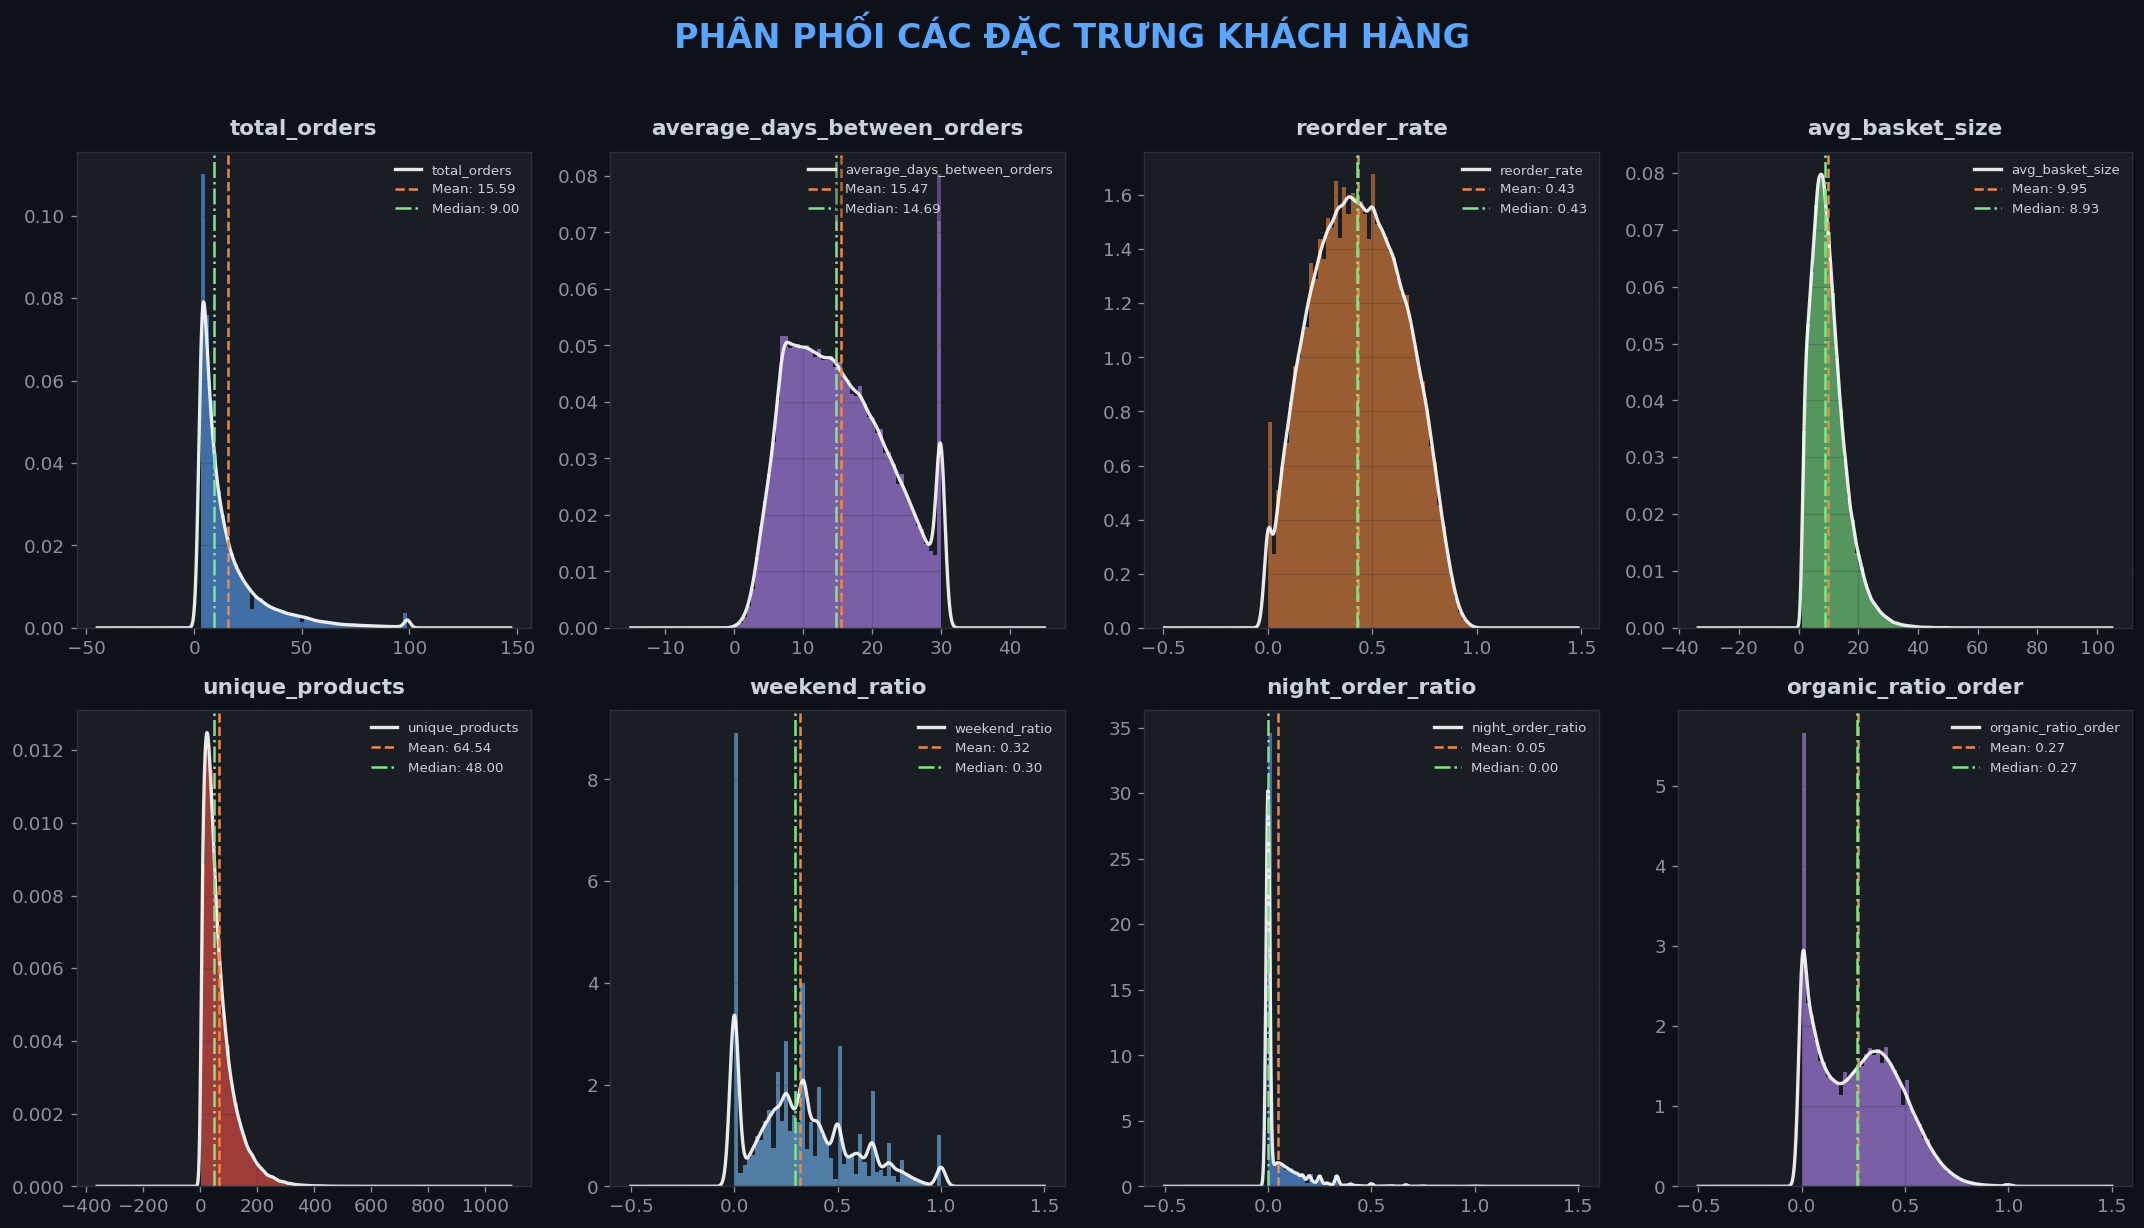

💾 Saved: dist_features.png


In [5]:
# Distribution plots - Histogram + KDE cho mỗi feature
features = ['total_orders', 'average_days_between_orders', 'reorder_rate',
             'avg_basket_size', 'unique_products', 'weekend_ratio', 'night_order_ratio', 'organic_ratio_order']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('PHÂN PHỐI CÁC ĐẶC TRƯNG KHÁCH HÀNG', fontsize=20, fontweight='bold',
             color='#58a6ff', y=1.02)

for idx, feature in enumerate(features):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    color = COLORS['gradient'][idx % len(COLORS['gradient'])]
    
    # Histogram with KDE
    data = df[feature].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.6, edgecolor='none', density=True)
    data.plot.kde(ax=ax, color='white', linewidth=2, alpha=0.9)
    
    # Mean & Median lines
    ax.axvline(data.mean(), color='#f0883e', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='#7ee787', linestyle='-.', linewidth=1.5, label=f'Median: {data.median():.2f}')
    
    ax.set_title(feature, fontsize=13, pad=10)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.3, edgecolor='none')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.2)

# Hide unused subplots
for idx in range(len(features), 8):
    row, col = divmod(idx, 4)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('dist_features.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('💾 Saved: dist_features.png')

## 3. 📦 Box Plot - Phát hiện Outliers

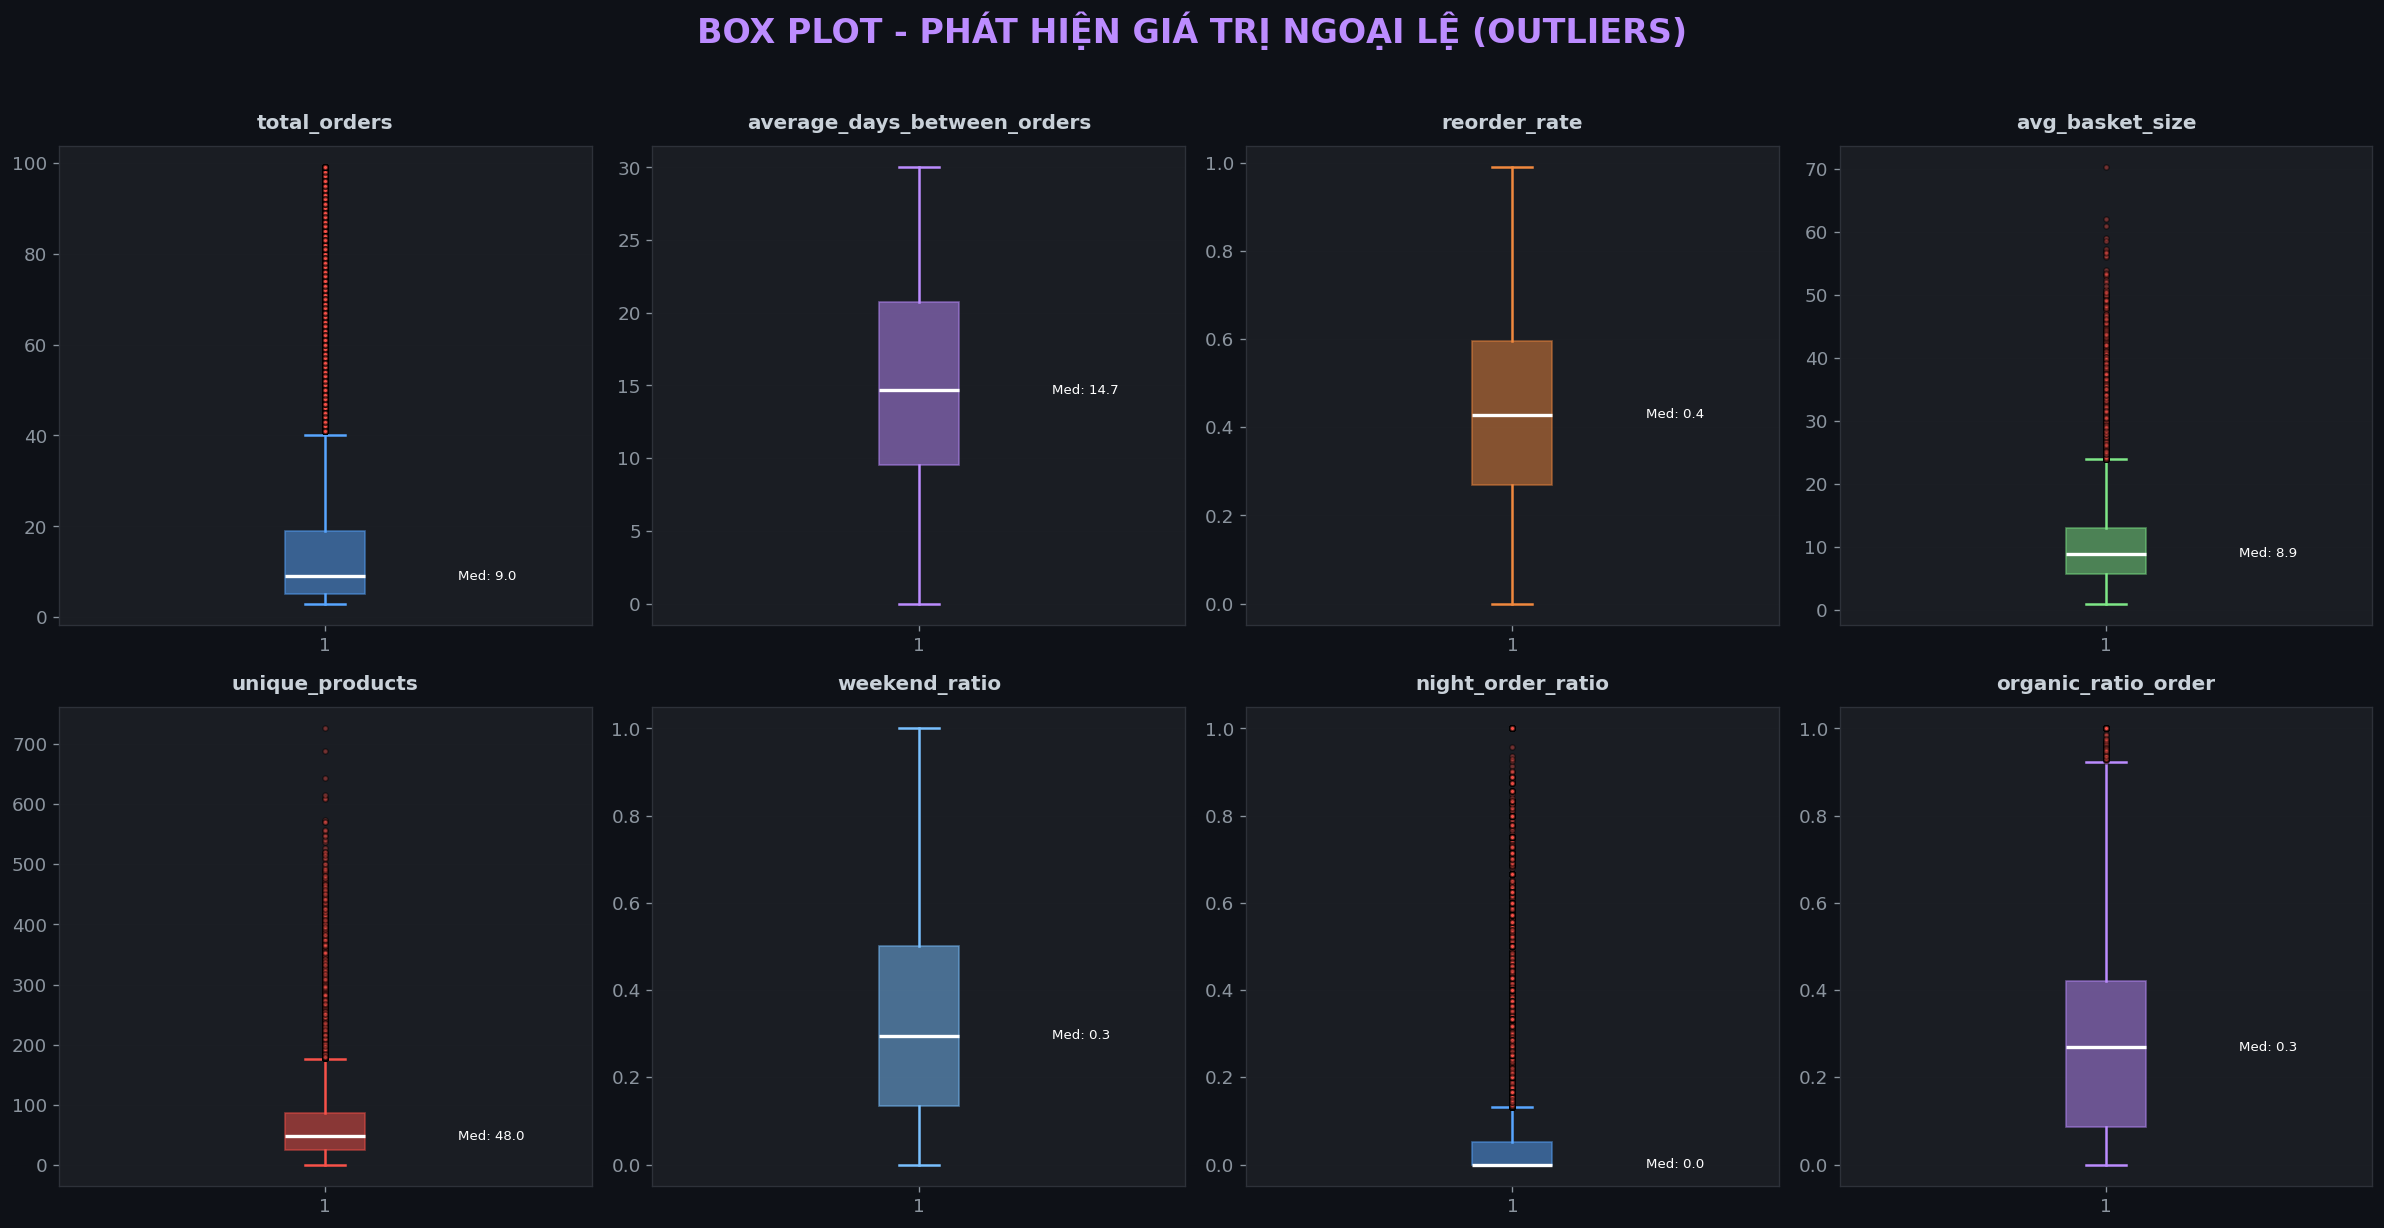

💾 Saved: boxplot_features.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('BOX PLOT - PHÁT HIỆN GIÁ TRỊ NGOẠI LỆ (OUTLIERS)', fontsize=20,
             fontweight='bold', color='#bc8cff', y=1.02)

for idx, feature in enumerate(features):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    color = COLORS['gradient'][idx % len(COLORS['gradient'])]
    
    bp = ax.boxplot(df[feature].dropna(), patch_artist=True, vert=True,
                    boxprops=dict(facecolor=color, alpha=0.5, edgecolor=color),
                    whiskerprops=dict(color=color, linewidth=1.5),
                    capprops=dict(color=color, linewidth=1.5),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#f85149', markersize=3, alpha=0.4))
    
    ax.set_title(feature, fontsize=12, pad=10)
    ax.grid(True, alpha=0.2, axis='y')
    
    # Annotate Q1, Median, Q3
    q1, med, q3 = df[feature].quantile([0.25, 0.5, 0.75])
    ax.text(1.25, med, f'Med: {med:.1f}', fontsize=8, color='white', va='center')

# Hide unused subplots
for idx in range(len(features), 8):
    row, col = divmod(idx, 4)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('boxplot_features.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('💾 Saved: boxplot_features.png')

## 4. 🔥 Correlation Heatmap

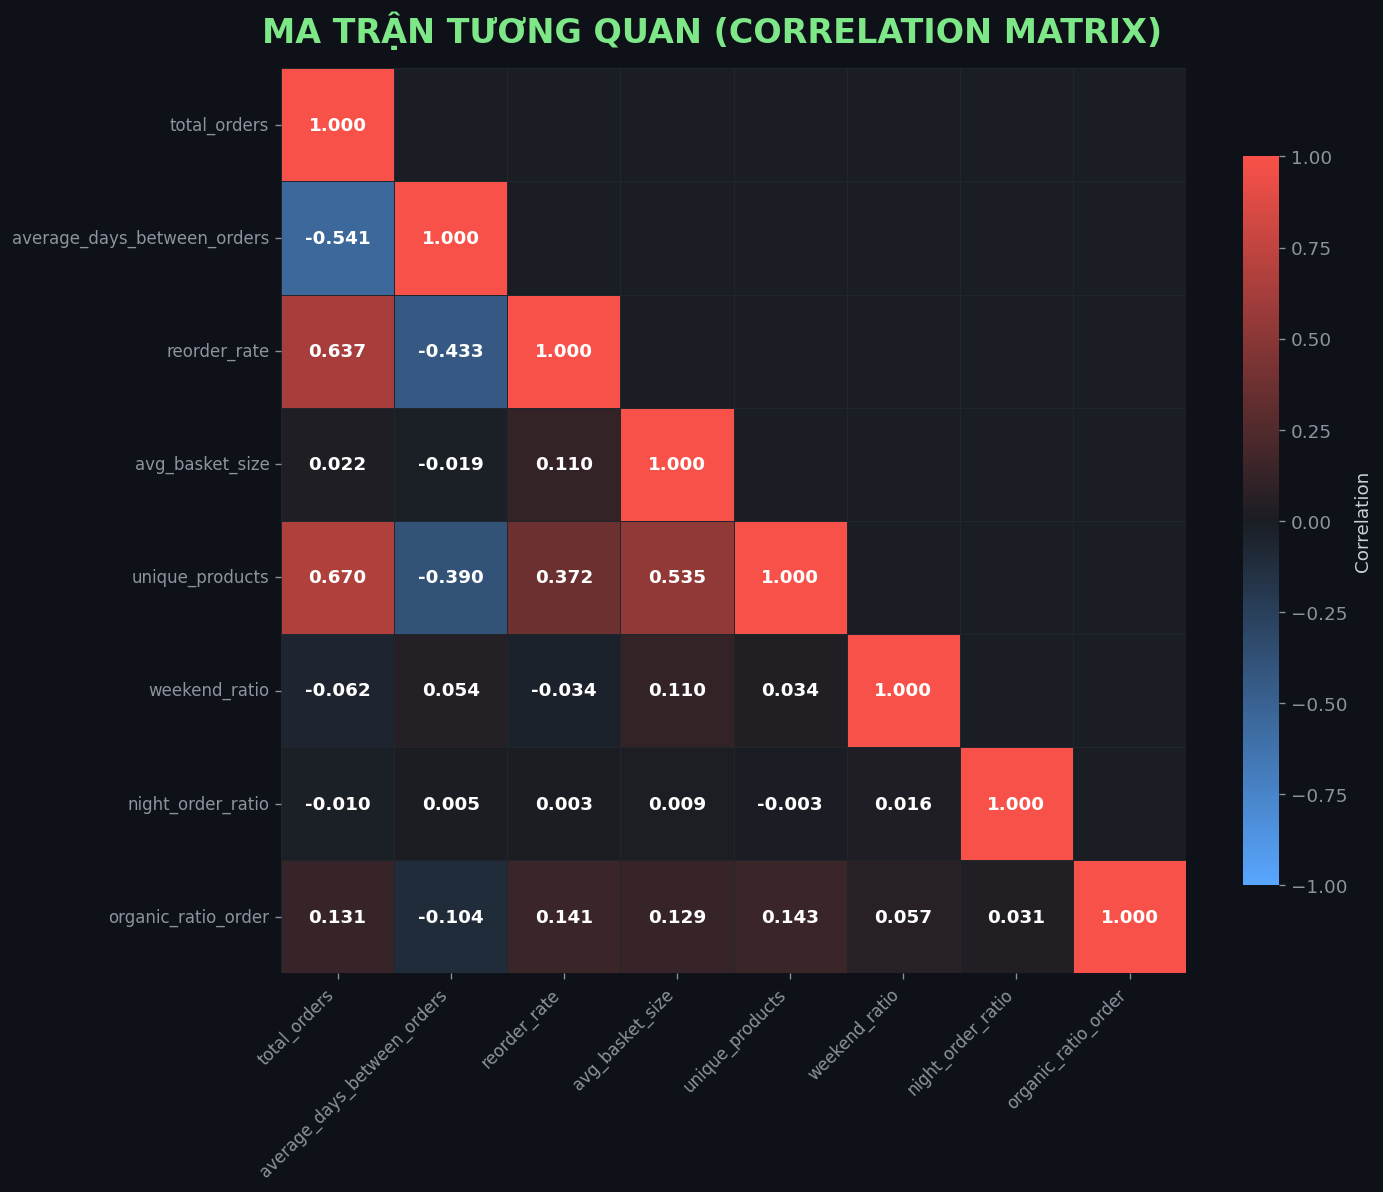

💾 Saved: correlation_heatmap.png


In [7]:
# Correlation heatmap
corr_matrix = df[features].corr()

# Custom diverging colormap
colors_cmap = ['#0d1117', '#1a1d23', '#58a6ff', '#7ee787', '#f0883e', '#f85149']
custom_cmap = LinearSegmentedColormap.from_list('custom_diverging',
    ['#58a6ff', '#1a1d23', '#f85149'], N=256)

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX)', fontsize=20,
             fontweight='bold', color='#7ee787', y=0.98)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap=custom_cmap,
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='#21262d',
            square=True, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold', 'color': 'white'},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('💾 Saved: correlation_heatmap.png')

---

# ⚙️ K-Means Clustering

Phần tiếp theo thực hiện phân cụm K-Means trên bộ dữ liệu `customer_features.csv` đã được phân tích ở trên.

### Các bước chính

1. Chuẩn bị dữ liệu và sao chép bộ dữ liệu gốc
2. Xử lý ngoại lệ (outliers) với phương pháp IQR
3. Chuẩn hóa dữ liệu và sử dụng Elbow Method để khám phá k
4. Chọn số cụm tối ưu bằng Silhouette Score
5. Huấn luyện K-means, đánh giá và trực quan hóa
6. Xuất kết quả phân cụm sang CSV

---

## 1. Chuẩn bị dữ liệu K-means

Cell này sao chép dataset đã load trước đó thành `df_customer`, để phần phân cụm vận hành trên một bản sao dữ liệu riêng và giữ nguyên dữ liệu gốc cho phần phân tích phía trên.

In [8]:
# === Bridge: Sử dụng dữ liệu đã load từ phần check_data ===
# Biến df đã được load ở phần trên, gán lại cho df_customer
df_customer = df.copy()
print(f'📦 Đã sử dụng dữ liệu customer: {df_customer.shape[0]:,} khách hàng × {df_customer.shape[1]} features')
print(f'Features: {list(df_customer.columns)}')
print(df_customer.head())

📦 Đã sử dụng dữ liệu customer: 206,209 khách hàng × 10 features
Features: ['user_id', 'total_orders', 'average_days_between_orders', 'reorder_rate', 'avg_basket_size', 'unique_products', 'product_diversity', 'weekend_ratio', 'night_order_ratio', 'organic_ratio_order']
   user_id  total_orders  average_days_between_orders  reorder_rate  \
0        1            10                    20.259259      0.694915   
1        2            14                    15.967033      0.476923   
2        3            12                    11.487179      0.625000   
3        4             5                    15.357143      0.055556   
4        5             4                    14.500000      0.378378   

   avg_basket_size  unique_products  product_diversity  weekend_ratio  \
0         5.900000               18           0.305085           0.00   
1        13.928571              102           0.523077           0.00   
2         7.333333               33           0.375000           0.50   
3         3.

## 2. Loại bỏ outliers bằng phương pháp IQR

Cell này sử dụng phương pháp IQR để giới hạn các giá trị ngoại lệ trên các biến số, giúp giảm ảnh hưởng của outliers trong quá trình phân cụm.

In [9]:
# Xử lý outliers bằng IQR method
import numpy as np

df_delete_outlier = df_customer.copy()

# Lặp qua các cột numerical (bỏ user_id)
numerical_cols = df_customer.select_dtypes(include=[np.number]).columns.drop('user_id')

for col in numerical_cols:
    Q1 = df_customer[col].quantile(0.25)
    Q3 = df_customer[col].quantile(0.75)
    IQR = Q3 - Q1

    # Giới hạn dưới và trên
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers về giới hạn
    df_delete_outlier[col] = np.where(df_delete_outlier[col] < lower_bound, lower_bound,
                                      np.where(df_delete_outlier[col] > upper_bound, upper_bound,
                                               df_delete_outlier[col]))

print(f'Đã xử lý outliers cho {len(numerical_cols)} cột numerical.')
print(f'Kích thước dữ liệu sau xử lý: {df_delete_outlier.shape}')
print('Thống kê trước và sau cho tất cả 9 biến:')
for col in numerical_cols:
    print(f'{col}: min={df_customer[col].min():.3f}, max={df_customer[col].max():.3f} -> min={df_delete_outlier[col].min():.3f}, max={df_delete_outlier[col].max():.3f}')

Đã xử lý outliers cho 9 cột numerical.
Kích thước dữ liệu sau xử lý: (206209, 10)
Thống kê trước và sau cho tất cả 9 biến:
total_orders: min=3.000, max=99.000 -> min=3.000, max=40.000
average_days_between_orders: min=0.000, max=30.000 -> min=0.000, max=30.000
reorder_rate: min=0.000, max=0.990 -> min=0.000, max=0.990
avg_basket_size: min=1.000, max=70.250 -> min=1.000, max=23.889
unique_products: min=1.000, max=726.000 -> min=1.000, max=177.500
product_diversity: min=0.010, max=1.000 -> min=0.010, max=1.000
weekend_ratio: min=0.000, max=1.000 -> min=0.000, max=1.000
night_order_ratio: min=0.000, max=1.000 -> min=0.000, max=0.132
organic_ratio_order: min=0.000, max=1.000 -> min=0.000, max=0.924


## 3. Chuẩn hóa và chọn k với Elbow Method

Cell này chuẩn hóa dữ liệu với `MinMaxScaler`, sau đó chạy K-means với các giá trị k từ 1 đến 10 và dùng biểu đồ Elbow để tìm điểm gãy (knee) của SSE.

SSE: [129672.5030832846, 96540.11784635755, 74071.07959951843, 66917.58841839786, 61776.42242692141, 57610.5373389609, 53949.25679671258, 51556.41292160989, 49407.792713254705, 47521.83371418564]
Silhouette Scores (k=2 to 10): [0.2562, 0.3024, 0.2016, 0.1989, 0.1936, 0.1919, 0.179, 0.1756, 0.1593]
Knee detected at k=3
Optimal k by Silhouette Score: 3


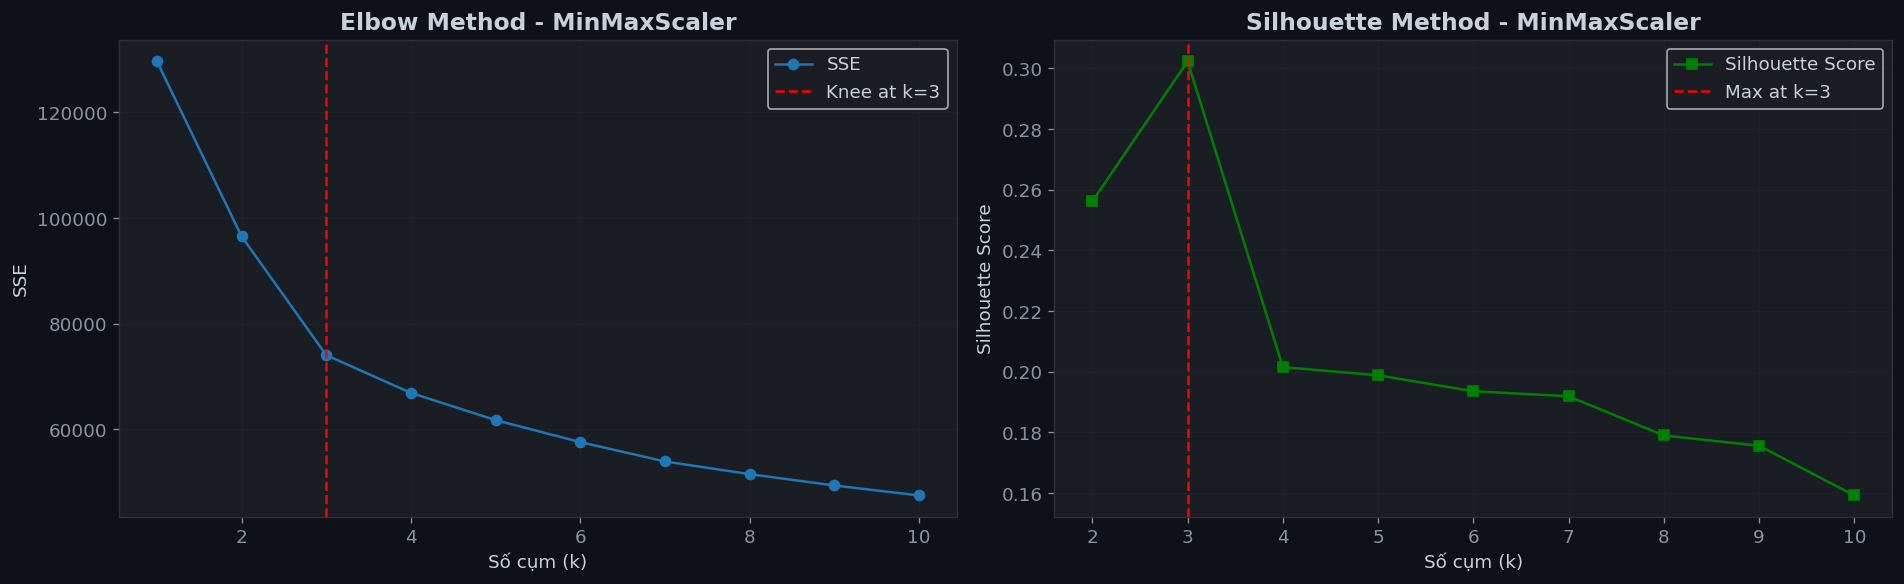


Tóm tắt:
MinMaxScaler: Optimal k (Elbow) = 3, Optimal k (Silhouette) = 3


In [10]:
# Thử nghiệm MinMaxScaler và tự động chọn k
from sklearn.preprocessing import MinMaxScaler
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Định nghĩa X
X = df_delete_outlier.drop('user_id', axis=1)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Elbow & Silhouette
sse = []
sil_scores = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sse.append(kmeans.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))

# Tự động detect knee
kneelocator = KneeLocator(list(k_range), sse, curve='convex', direction='decreasing')
optimal_k = kneelocator.knee

print(f'SSE: {sse}')
print(f'Silhouette Scores (k=2 to 10): {[round(s, 4) for s in sil_scores]}')
print(f'Knee detected at k={optimal_k}')

# Tính optimal Silhouette 
k_range_sil = list(range(2, 11))
optimal_k_sil = k_range_sil[sil_scores.index(max(sil_scores))]
print(f'Optimal k by Silhouette Score: {optimal_k_sil}')

# Vẽ đồ thị
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị Elbow
ax1.plot(list(k_range), sse, marker='o', label='SSE')
if optimal_k:
    ax1.axvline(x=optimal_k, color='r', linestyle='--', label=f'Knee at k={optimal_k}')
ax1.set_xlabel('Số cụm (k)')
ax1.set_ylabel('SSE')
ax1.set_title('Elbow Method - MinMaxScaler')
ax1.legend()
ax1.grid(True)

# Đồ thị Silhouette
ax2.plot(k_range_sil, sil_scores, marker='s', color='g', label='Silhouette Score')
ax2.axvline(x=optimal_k_sil, color='r', linestyle='--', label=f'Max at k={optimal_k_sil}')
ax2.set_xlabel('Số cụm (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Method - MinMaxScaler')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

results = {'MinMaxScaler': {'sse': sse, 'sil_scores': sil_scores, 'optimal_k': optimal_k, 'optimal_k_sil': optimal_k_sil, 'X_scaled': X_scaled}}

print('\nTóm tắt:')
print(f'MinMaxScaler: Optimal k (Elbow) = {optimal_k}, Optimal k (Silhouette) = {optimal_k_sil}')

## 4. Huấn luyện K-means và trực quan hóa kết quả

Cell này huấn luyện mô hình K-means với k đã chọn, gắn nhãn cụm vào dữ liệu và hiển thị kết quả phân bố cụm trên không gian hai thành phần chính PCA.

Siêu tham số của K-means:
n_clusters: 3
init: k-means++
n_init: 10
max_iter: 300
tol: 0.0001
random_state: 42

Số lần lặp thực tế: 18
Inertia (SSE): 74071.08

Phân cụm với 3 cụm (MinMaxScaler):
Cụm 0: 113906 khách (55.2%)
Cụm 1: 40204 khách (19.5%)
Cụm 2: 52099 khách (25.3%)
Silhouette Score: 0.3024


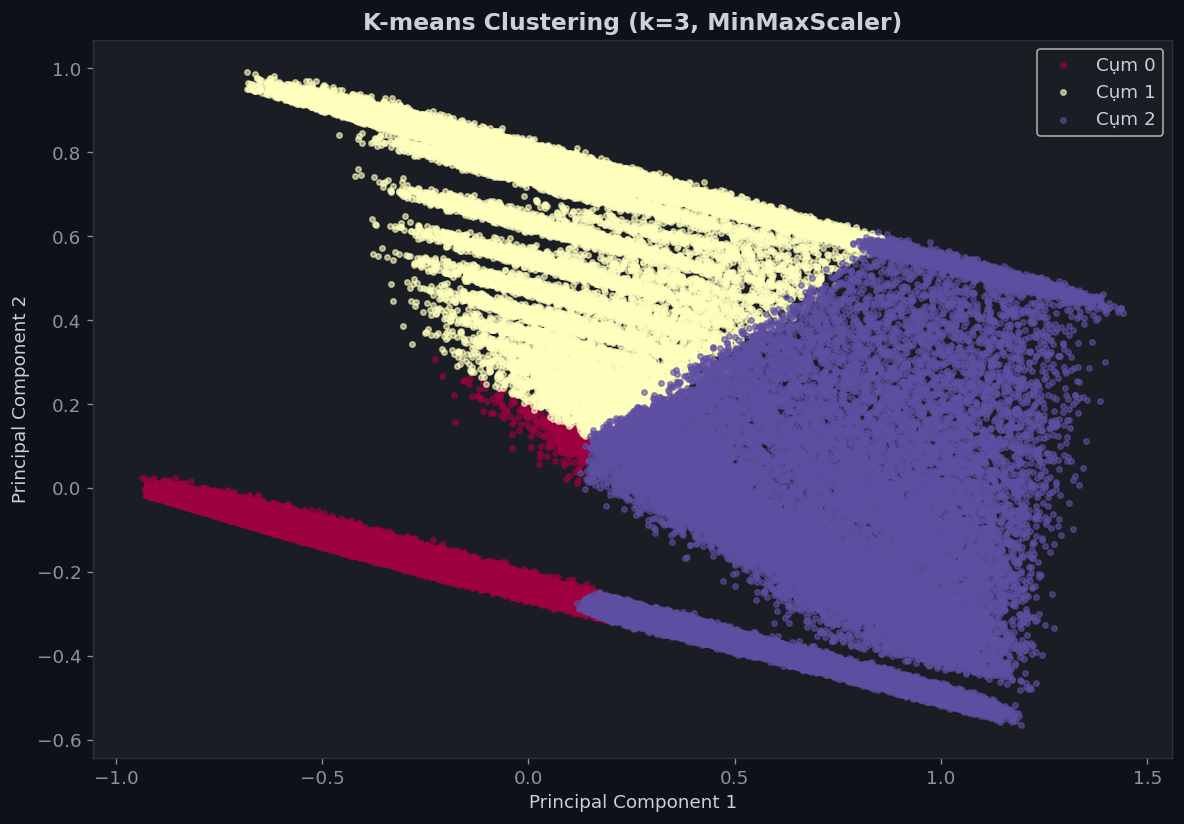

Đã lưu biểu đồ kmeans_minmax_k3.png


In [11]:
# Phân cụm với MinMaxScaler và k tối ưu từ Silhouette Score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Lấy X_scaled từ MinMaxScaler và k tối ưu
X_scaled = results['MinMaxScaler']['X_scaled']
k = results['MinMaxScaler']['optimal_k']

# Siêu tham số của K-means
kmeans_params = {
    'n_clusters': k,
    'init': 'k-means++',  # Phương pháp khởi tạo centroids
    'n_init': 10,  # Số lần chạy với centroids khác nhau
    'max_iter': 300,  # Số lần lặp tối đa
    'tol': 1e-4,  # Ngưỡng hội tụ
    'random_state': 42  # Để reproducible
}

print('Siêu tham số của K-means:')
for param, value in kmeans_params.items():
    print(f'{param}: {value}')

# Chạy K-means
kmeans = KMeans(**kmeans_params)
clusters = kmeans.fit_predict(X_scaled)

print(f'\nSố lần lặp thực tế: {kmeans.n_iter_}')
print(f'Inertia (SSE): {kmeans.inertia_:.2f}')

# Thêm nhãn cụm vào dataframe
df_clustered = df_delete_outlier.copy()
df_clustered['cluster'] = clusters

# Thống kê cụm
cluster_counts = pd.Series(clusters).value_counts().sort_index()
print(f'\nPhân cụm với {k} cụm (MinMaxScaler):')
for cluster, count in cluster_counts.items():
    pct = count / len(clusters) * 100
    print(f'Cụm {cluster}: {count} khách ({pct:.1f}%)')

# Đánh giá Silhouette Score
sil_score = silhouette_score(X_scaled, clusters, sample_size=10000, random_state=42)
print(f'Silhouette Score: {sil_score:.4f}')

# Trực quan hóa trên PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clustered['PC1'] = X_pca[:, 0]
df_clustered['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
colors = plt.cm.Spectral(np.linspace(0, 1, k))
for cluster in range(k):
    mask = clusters == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[cluster]], s=10, alpha=0.6, label=f'Cụm {cluster}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-means Clustering (k={k}, MinMaxScaler)')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_minmax_k3.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ kmeans_minmax_k3.png')

## 6. Phân tích và trực quan hóa profile cụm

Cell này tạo các biểu đồ bổ sung như pie chart, radar chart và histogram để trực quan hóa đặc điểm trung bình của từng cụm và sự phân bố các khách hàng.

Trung bình các feature theo cụm:
         total_orders  average_days_between_orders  reorder_rate  \
cluster                                                            
0            7.359261                    17.891808      0.338630   
1           11.001418                    16.454281      0.413732   
2           30.526843                     9.414248      0.651222   

         avg_basket_size  unique_products  product_diversity  weekend_ratio  \
cluster                                                                       
0               9.270751        40.359178           0.661370       0.321765   
1               9.465766        53.098199           0.586268       0.335171   
2              11.315642       115.145108           0.348778       0.305411   

         night_order_ratio  organic_ratio_order  
cluster                                          
0                 0.000151             0.250235  
1                 0.118700             0.274056  
2                 0.028348    

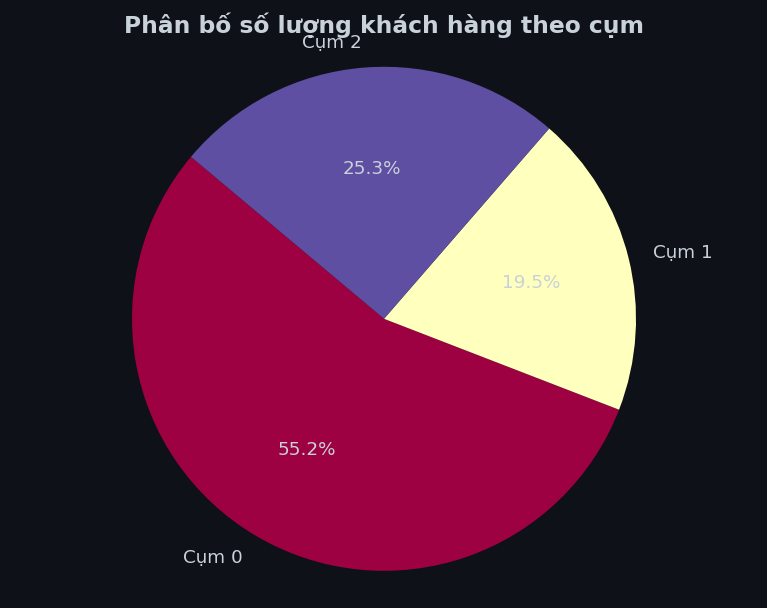

Đã lưu biểu đồ cluster_pie_chart.png


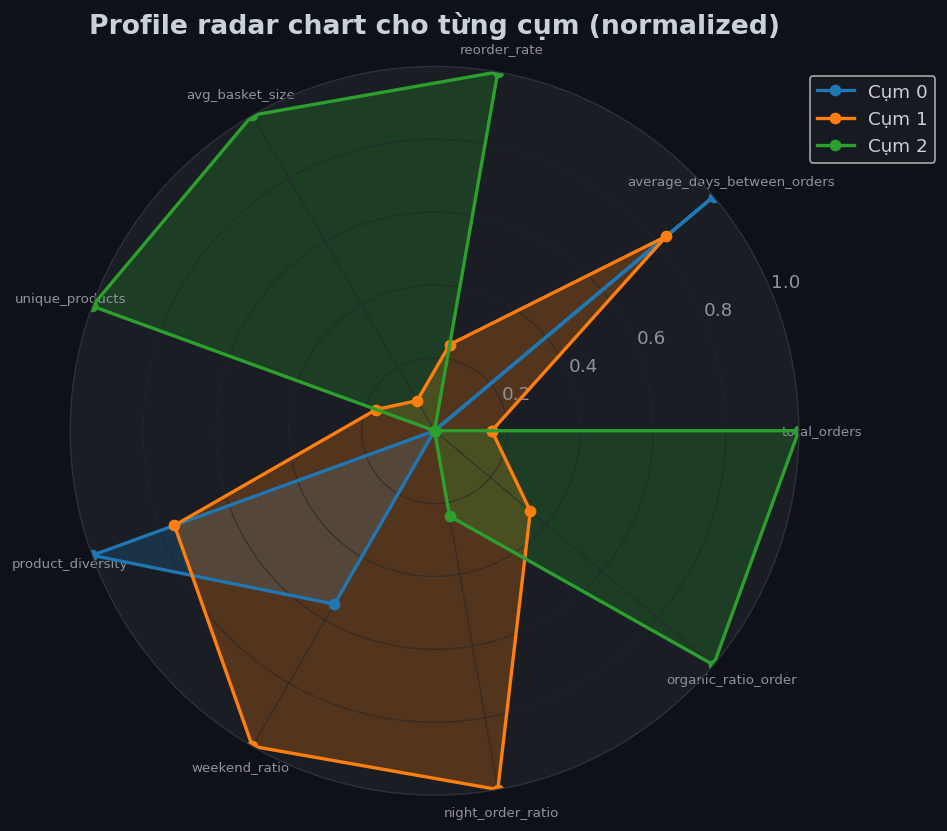

Đã lưu biểu đồ cluster_radar_chart.png


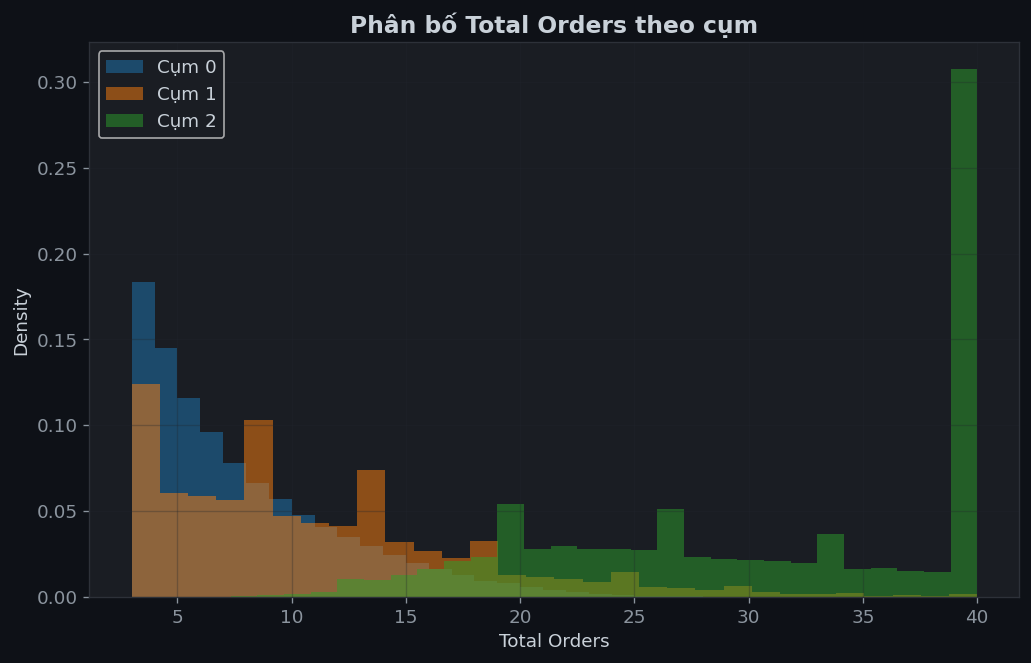

Đã lưu biểu đồ total_orders_histogram.png


In [12]:
# Biểu đồ bổ sung để minh họa kết quả
import matplotlib.pyplot as plt
import seaborn as sns

# Trung bình các feature theo cụm
cluster_profiles = df_clustered.groupby('cluster')[numerical_cols].mean()
print('Trung bình các feature theo cụm:')
print(cluster_profiles)

# 1. Pie chart cho phân bố cụm
plt.figure(figsize=(8, 6))
plt.pie(cluster_counts, labels=[f'Cụm {i}' for i in cluster_counts.index], autopct='%1.1f%%', startangle=140, colors=plt.cm.Spectral(np.linspace(0, 1, len(cluster_counts))))
plt.title('Phân bố số lượng khách hàng theo cụm')
plt.axis('equal')
plt.savefig('cluster_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ cluster_pie_chart.png')

# 2. Radar chart cho profile từng cụm (normalized)
from math import pi

# Chuẩn hóa cluster_profiles về 0-1 cho radar
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

# Categories
categories = list(cluster_profiles.columns)
N = len(categories)

# Angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

for i in range(len(cluster_profiles)):
    values = cluster_profiles_norm.iloc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cụm {i}')
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Profile radar chart cho từng cụm (normalized)', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.tight_layout()
plt.savefig('cluster_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ cluster_radar_chart.png')

# 3. Histogram cho total_orders theo cụm
plt.figure(figsize=(10, 6))
for cluster in range(3):  # 3 cụm
    subset = df_clustered[df_clustered['cluster'] == cluster]
    plt.hist(subset['total_orders'], bins=30, alpha=0.5, label=f'Cụm {cluster}', density=True)

plt.xlabel('Total Orders')
plt.ylabel('Density')
plt.title('Phân bố Total Orders theo cụm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('total_orders_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ total_orders_histogram.png')

## 7. Xuất kết quả phân cụm

Cell này lưu dataframe cuối cùng gồm nhãn cụm và các cột đã chuẩn hóa ra CSV, để dùng cho báo cáo hoặc phân tích tiếp theo.

In [13]:
# Xuất dữ liệu gốc với nhãn cụm và cột chuẩn hóa
df_customer_with_clusters = df_customer.copy()
df_customer_with_clusters['cluster'] = clusters

# Thêm cột chuẩn hóa
X_scaled_df = pd.DataFrame(X_scaled, columns=[f'{col}_scaled' for col in numerical_cols])
df_customer_with_clusters = pd.concat([df_customer_with_clusters, X_scaled_df], axis=1)

# Xuất ra CSV
output_file = 'customer_segmentation.csv'
df_customer_with_clusters.to_csv(output_file, index=False)
print(f'Đã xuất dữ liệu ra file: {output_file}')
print(f'Kích thước: {df_customer_with_clusters.shape}')
print('Preview:')
print(df_customer_with_clusters.head())

Đã xuất dữ liệu ra file: customer_segmentation.csv
Kích thước: (206209, 20)
Preview:
   user_id  total_orders  average_days_between_orders  reorder_rate  \
0        1            10                    20.259259      0.694915   
1        2            14                    15.967033      0.476923   
2        3            12                    11.487179      0.625000   
3        4             5                    15.357143      0.055556   
4        5             4                    14.500000      0.378378   

   avg_basket_size  unique_products  product_diversity  weekend_ratio  \
0         5.900000               18           0.305085           0.00   
1        13.928571              102           0.523077           0.00   
2         7.333333               33           0.375000           0.50   
3         3.600000               17           0.944444           0.20   
4         9.250000               23           0.621622           0.25   

   night_order_ratio  organic_ratio_order  cluste

# Tóm tắt và Trình bày về File Phân tích

## Mục đích của Notebook
Notebook này thực hiện phân tích phân cụm khách hàng sử dụng thuật toán K-means trên dữ liệu từ Instacart. Mục tiêu là chia khách hàng thành các nhóm dựa trên hành vi mua sắm để hỗ trợ chiến lược marketing và cá nhân hóa dịch vụ.

## Các Bước Phân tích Chính
1. **Tiền xử lý dữ liệu**: Loại bỏ outliers bằng phương pháp IQR để đảm bảo chất lượng dữ liệu.
2. **Chuẩn hóa dữ liệu**: Sử dụng MinMaxScaler để đưa các đặc trưng về cùng thang đo.
3. **Chọn số cụm tối ưu**: Áp dụng Silhouette Score để xác định số cụm k=3 là tối ưu.
4. **Phân cụm K-means**: Chạy thuật toán với các siêu tham số đã tối ưu.
5. **Trực quan hóa**: Sử dụng PCA, biểu đồ tròn, radar chart và histogram để minh họa kết quả.
6. **Xuất dữ liệu**: Lưu kết quả phân cụm và dữ liệu chuẩn hóa ra file CSV.

## Kết quả Chính
- **Số cụm**: 3 cụm với Silhouette Score = 0.3024
- **Phân bố cụm**:
  - Cụm 0: Khách hàng có mức độ tương tác thấp
  - Cụm 1: Khách hàng có mức độ tương tác trung bình
  - Cụm 2: Khách hàng có mức độ tương tác cao
- **File xuất**: `customer_features_with_clusters_and_scaled_k3.csv` chứa dữ liệu gốc, nhãn cụm và các cột chuẩn hóa.

## Ý nghĩa Kinh doanh
Phân tích này giúp xác định các nhóm khách hàng khác nhau, từ đó có thể:
- Tối ưu hóa chiến dịch marketing cho từng nhóm
- Cải thiện trải nghiệm mua sắm
- Dự đoán hành vi khách hàng trong tương lai

## Lưu ý
- Dữ liệu được xử lý để loại bỏ outliers và chuẩn hóa
- Sử dụng MinMaxScaler cho kết quả tốt nhất
- Kết quả có thể được sử dụng cho các phân tích tiếp theo hoặc mô hình dự đoán